# Predicting Nairobi Housing Prices

A regression project: build and tune a machine learning model to predict residential property values across the Nairobi metropolitan area, and evaluate how reliable those predictions are.

### A note on this dataset

The dataset comprises real estate listings collected from Property24, a leading property platform in Kenya. Unlike historical benchmarks like the Boston housing dataset which utilized synthesized socioeconomic proxies, this dataset captures live market transactions and asking prices directly from property sellers and developers.

Because these figures represent active listing prices rather than closed deed registrations, values inherently reflect current seller sentiment, infrastructure premiums, and speculative margins. The data serves as an empirical foundation for hedonic valuation, capturing structural specifications alongside high-demand metropolitan micro-markets.

In this project, we will evaluate the performance and predictive power of a model that has been trained and tested on data collected from properties across various neighborhoods in Nairobi. A model trained on this data that is seen as a good fit could then be used to make clear, objective predictions about a home's monetary value for property developers, financial institutions, and home buyers.

### Problem Statement

Urban real estate in Nairobi is characterized by high price volatility, rapid infrastructure changes, and informational asymmetry between buyers and sellers. Without standardized pricing mechanisms, estimating the fair monetary value of residential properties remains challenging.

This project aims to address this challenge by developing a predictive regression model that maps property attributes, specifically structural elements like bedrooms, bathrooms, and size, combined with spatial location, to listing prices. The resulting framework provides a transparent benchmark to assess whether a property is underpriced, fairly valued, or priced at an unsustainable premium.

### Data Overview & Scope

The raw data records multiple property attributes:

* **Target:** Property price (KES).
* **Structural Features:** Number of bedrooms, bathrooms, property type, and recorded size.
* **Spatial & Descriptive Features:** Neighborhood location, listing description, and current market status.

We'll begin by loading the dataset, conducting an initial structural audit including data exploration, cleaning, formatting inconsistencies, checking for extreme values, and separating the features or the predictors from the target property values for regression analysis in this case house price.

In [2]:
# Let's import all the libraries necessary for this project
# To begin with, we will import numpy and pandas for data manipilations and mathematical operations
import numpy as np
import pandas as pd
# setting up charts to display inside the notebook and format the table numbers
%matplotlib inline
pd.set_option('display.max_columns', None)

# restricting the float value to 2 decimal places
pd.set_option('display.float_format', lambda x: '%.2f' % x)


In [3]:
# Importing the Nairobi housing dataset
data = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\R projects\Dr. Troon R Sessions\Datasets\Nairobi property prices\data\nairobi_house_prices.csv")

# Viewing the first and last five rows of the dataset
data.head()

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,KSh 350 000 000,Townhouse,Runda,4.00,4.00,NaN,0.5 acres
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,KSh 80 000 000,Townhouse,Kitisuru,5.00,5.00,NaN,0.5 acres
4,KSh 25 500 000,Apartment,Kileleshwa,4.00,4.00,230 m²,NaN


In [4]:
data.tail()


,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
199,KSh 6 000 000,Apartment,Westlands,1.00,1.00,60 m²,NaN
200,Ksh 200 000 000,Townhouse,Runda,8.00,7.00,NaN,0.5 acres
201,Ksh 9 500 000,Apartment,Nairobi West,2.00,2.00,NaN,NaN
202,KSh 12 500 000,Apartment,Kilimani,2.00,1.00,96 m²,NaN
203,KSh 28 000 000,Townhouse,Kiambu Road,4.00,3.00,234 m²,NaN


## Data Exploration

In this section, the data scientist conducts an initial exploration of the Nairobi housing dataset.

The core objective of this project is to construct a regression model capable of predicting property prices within the Nairobi metropolitan area. To achieve this, the dataset will eventually be partitioned into feature variables and the target response:

* **Predictor Features:** Property characteristics such as `propertyType`, `Location`, `Bedroom`, `bathroom`, `House size`, and `Land size`, which supply qualitative spatial context and quantitative structural dimensions for each listing.
* **Target Variable:** `Price`, representing the continuous monetary listing valuation we seek to model and predict.

Before isolating features and target variables or training any algorithms, we must examine data types, assess missing values, and standardize structural formats across all columns.

In [6]:
# Understanding the shape of the dataset
print('There are', data.shape[0], 'rows and', data.shape[1], 'columns.')

There are 204 rows and 7 columns.


In [7]:
# Let's also confirm the column data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         204 non-null    object 
 1   propertyType  204 non-null    object 
 2   Location      204 non-null    object 
 3   Bedroom       183 non-null    float64
 4   bathroom      181 non-null    float64
 5   House size    99 non-null     object 
 6   Land size     64 non-null     object 
dtypes: float64(2), object(5)
memory usage: 11.3+ KB


* There are 2 numerical columns in the data and 5 object type columns.
* Price is being read as an object type column, but it should be a numerical column representing property value.
* House size and Land size are being read as object type columns, but they should be converted to numeric values after stripping unit labels (such as m² and acres).
* Bedroom and bathroom are numerical (float64), but contain missing values largely attributed to non-residential listings such as vacant land.


In [8]:
# I begin the standardization of formats and we will commence with data types.
# Cleaning Price by replacing text and spaces directly
data['Price'] = data['Price'].str.replace('KSh', '')
data['Price'] = data['Price'].str.replace('Ksh', '')
data['Price'] = data['Price'].str.replace(' ', '')

# Converting dtype to numeric float
data['Price'] = data['Price'].astype(float)

# Checking the result
data['Price'].head()


0   350000000.00
1    30000000.00
2   325000000.00
3    80000000.00
4    25500000.00
Name: Price, dtype: float64

In [9]:
# Cleaning House size by removing units and extra spaces
data['House size'] = data['House size'].str.replace('m²', '')
data['House size'] = data['House size'].str.replace(',', '')
data['House size'] = data['House size'].str.strip()

# Converting dtype to float
data['House size'] = pd.to_numeric(data['House size'], errors='coerce')

# Checking the result
data['House size'].head()

0      NaN
1      NaN
2      NaN
3      NaN
4   230.00
Name: House size, dtype: float64

In [10]:
# Viewing rows where House size could not be converted
data[data['House size'].isna()]

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,350000000.00,Townhouse,Runda,4.00,4.00,NaN,0.5 acres
1,30000000.00,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,325000000.00,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,80000000.00,Townhouse,Kitisuru,5.00,5.00,NaN,0.5 acres
5,300000000.00,Townhuse,Runda,6.00,6.00,NaN,0.5 acres
...,...,...,...,...,...,...,...
195,13500000.00,Apartment,Riverside,2.00,2.00,NaN,NaN
197,60000000.00,Townhouse,Karen,4.00,3.00,NaN,0.5 acres
198,6730000.00,Townhouse,Lavington,1.00,1.00,NaN,NaN
200,200000000.00,Townhouse,Runda,8.00,7.00,NaN,0.5 acres


In [11]:
# Standardixzing Land size to numeric.
# Cleaning Land size by removing acres and converting to float
data['Land size'] = data['Land size'].str.replace('acres', '')
data['Land size'] = data['Land size'].str.replace(',', '')
data['Land size'] = data['Land size'].str.strip()

# Converting to float
data['Land size'] = pd.to_numeric(data['Land size'], errors='coerce')

# Checking the result
data['Land size'].head()

0   0.50
1   0.50
2   0.50
3   0.50
4    NaN
Name: Land size, dtype: float64

* Price has been stripped of currency prefixes (KSh/Ksh) and whitespace, and successfully converted from an object type to a float64 numerical column.
* House size has been cleaned by removing unit markers m² and formatting commas, and successfully converted from an object type to a float64 numerical column.
* Land size has been cleaned by removing the acres unit marker and whitespace, and successfully converted from an object type to a float64 numerical column.

In [35]:
# Standardizing column names to sentence case
data.columns = ['Price', 'Property type', 'Location', 'Bedroom', 'Bathroom', 'House size', 'Land size']

* Checking Categorical columns for inconsistencies

In [12]:
# We begin with Property type
# Checking unique values and frequencies in propertyType
data['propertyType'].value_counts(dropna=False)

propertyType
Apartment              104
Townhouse               78
Vacant Land             19
Townhuse                 1
Commercial Property      1
Industrial Property      1
Name: count, dtype: int64

* Apartment is the most common property type with 104 listings, followed by    Townhouse with 78 listings and Vacant Land with 19 listings.

* There is a spelling inconsistency where Townhuse appears once, which should  be corrected to Townhouse.

* Rare commercial categories exist in the dataset, specifically Commercial Property (1 entry) and Industrial Property (1 entry).

In [13]:
# Fixing the typo in propertyType
data['propertyType'] = data['propertyType'].replace('Townhuse', 'Townhouse')

# Verifying the updated value counts
data['propertyType'].value_counts()

propertyType
Apartment              104
Townhouse               79
Vacant Land             19
Commercial Property      1
Industrial Property      1
Name: count, dtype: int64

* The misspelling Townhuse has been corrected and merged into Townhouse, increasing its total count from 78 to 79.

* propertyType is now standardized into 5 distinct categories, with residential units (Apartment and Townhouse) accounting for the vast majority (183 out of 204) of listings.

In [14]:
# Next categorical column is Location
# Checking the unique locations and their frequencies
data['Location'].value_counts(dropna=False)

Location
Kilimani          37
Lavington         34
Westlands         27
Kileleshwa        22
Runda             20
Karen             14
Kitisuru           9
Riverside          6
Loresho            5
Nyari              5
Kiambu Road        4
Thigiri            3
Rosslyn            3
Ngong Rd           2
Nairobi West       2
Kyuna              1
Muthaiga North     1
Parklands          1
Thome              1
Kabete             1
Muthaiga           1
Ongata Rongai      1
Lower Kabete       1
Syokimau           1
Mombasa Rd         1
Waithaka           1
Name: count, dtype: int64

* Kilimani is the most represented location with 37 listings, followed closely by Lavington (34), Westlands (27), and Kileleshwa (22).

* High-end residential suburbs like Runda (20), Karen (14), and Kitisuru (9) comprise a significant share of property entries.

* The location names appear clean and standardized without visible spelling duplicates, though there are several low-frequency neighborhoods with only 1 listing each (such as Kyuna, Parklands, Ongata Rongai, and Syokimau).

In [15]:
# Stripping any leading or trailing whitespace from Location
data['Location'] = data['Location'].str.strip()

# Checking the final dataset structure and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         204 non-null    float64
 1   propertyType  204 non-null    object 
 2   Location      204 non-null    object 
 3   Bedroom       183 non-null    float64
 4   bathroom      181 non-null    float64
 5   House size    96 non-null     float64
 6   Land size     64 non-null     float64
dtypes: float64(5), object(2)
memory usage: 11.3+ KB


* There are now 5 numerical columns (Price, Bedroom, bathroom, House size, Land size) and 2 categorical object columns (propertyType, Location).
* All numerical features have been successfully converted to float64 format and are ready for mathematical computation.
* Price, propertyType, and Location have no missing entries (204 non-null values each).
* Missing values remain present in Bedroom (21 nulls), bathroom (23 nulls), House size (107 nulls), and Land size (140 nulls).

In [16]:
# Standardizing road naming conventions by replacing 'Road' with 'Rd'
data['Location'] = data['Location'].str.replace('Road', 'Rd')
data['Location'].value_counts()

Location
Kilimani          37
Lavington         34
Westlands         27
Kileleshwa        22
Runda             20
Karen             14
Kitisuru           9
Riverside          6
Loresho            5
Nyari              5
Kiambu Rd          4
Thigiri            3
Rosslyn            3
Ngong Rd           2
Nairobi West       2
Kyuna              1
Muthaiga North     1
Parklands          1
Thome              1
Kabete             1
Muthaiga           1
Ongata Rongai      1
Lower Kabete       1
Syokimau           1
Mombasa Rd         1
Waithaka           1
Name: count, dtype: int64

## Handling Missing Values

In [17]:
# Checking for the percentage of missing values per column
(data.isnull().sum() / len(data)) * 100

Price           0.00
propertyType    0.00
Location        0.00
Bedroom        10.29
bathroom       11.27
House size     52.94
Land size      68.63
dtype: float64

* Price, propertyType, and Location contain no missing entries (0.00% missing).
* Bedroom and bathroom exhibit mild missingness at 10.29% (21 listings) and 11.27% (23 listings) respectively.
* House size and Land size suffer from heavy missingness at 52.45% (107 listings) and 68.63% (140 listings) respectively.

In [18]:
# missing value counts grouped by propertyType
data.groupby('propertyType')[['Bedroom', 'bathroom', 'House size', 'Land size']].apply(lambda x: x.isnull().sum())

,Bedroom,bathroom,House size,Land size
propertyType,,,,
Apartment,0,2,29,95
Commercial Property,1,1,1,0
Industrial Property,1,1,1,0
Townhouse,0,0,59,42
Vacant Land,19,19,18,3


* Vacant Land accounts for 19 missing bedroom and bathroom values because undeveloped plots have no rooms.
* Commercial and Industrial properties lack room and house size values because they are non-residential.
* Apartments miss only two bathroom values and mostly lack land size because they report floor area instead.
* Townhouses have complete room counts but lack measurements in both house size and land size.

In [19]:
# Setting Bedroom and bathroom to 0 for non-residential types
types_with_zero_rooms = ['Vacant Land', 'Commercial Property', 'Industrial Property']
data.loc[data['propertyType'].isin(types_with_zero_rooms), ['Bedroom', 'bathroom']] = 0

# imputed missing bathrooms using median of matching property type and bedroom count
data['bathroom'] = data.groupby(['propertyType', 'Bedroom'])['bathroom'].transform(lambda x: x.fillna(x.median()))

data.isnull().sum()

Price             0
propertyType      0
Location          0
Bedroom           0
bathroom          0
House size      108
Land size       140
dtype: int64

* Missing values in Bedroom and bathroom for Vacant Land, Commercial Property, and Industrial Property were imputed with 0 to reflect the structural absence of residential living quarters.
* The 2 missing bathroom values for apartments were imputed using group-based conditional imputation based on the median bathroom count for apartments with the same bedroom count.
* Missing values in House size (107 missing) and Land size (140 missing) are intentionally left un-imputed because apartments typically report floor area while standalone houses and plots report acreage.
* Leaving both size variables intact prevents distorting summary statistics such as the mean, median, and standard deviation, preserving the true properties of the sample distribution.

## Handling Outliers

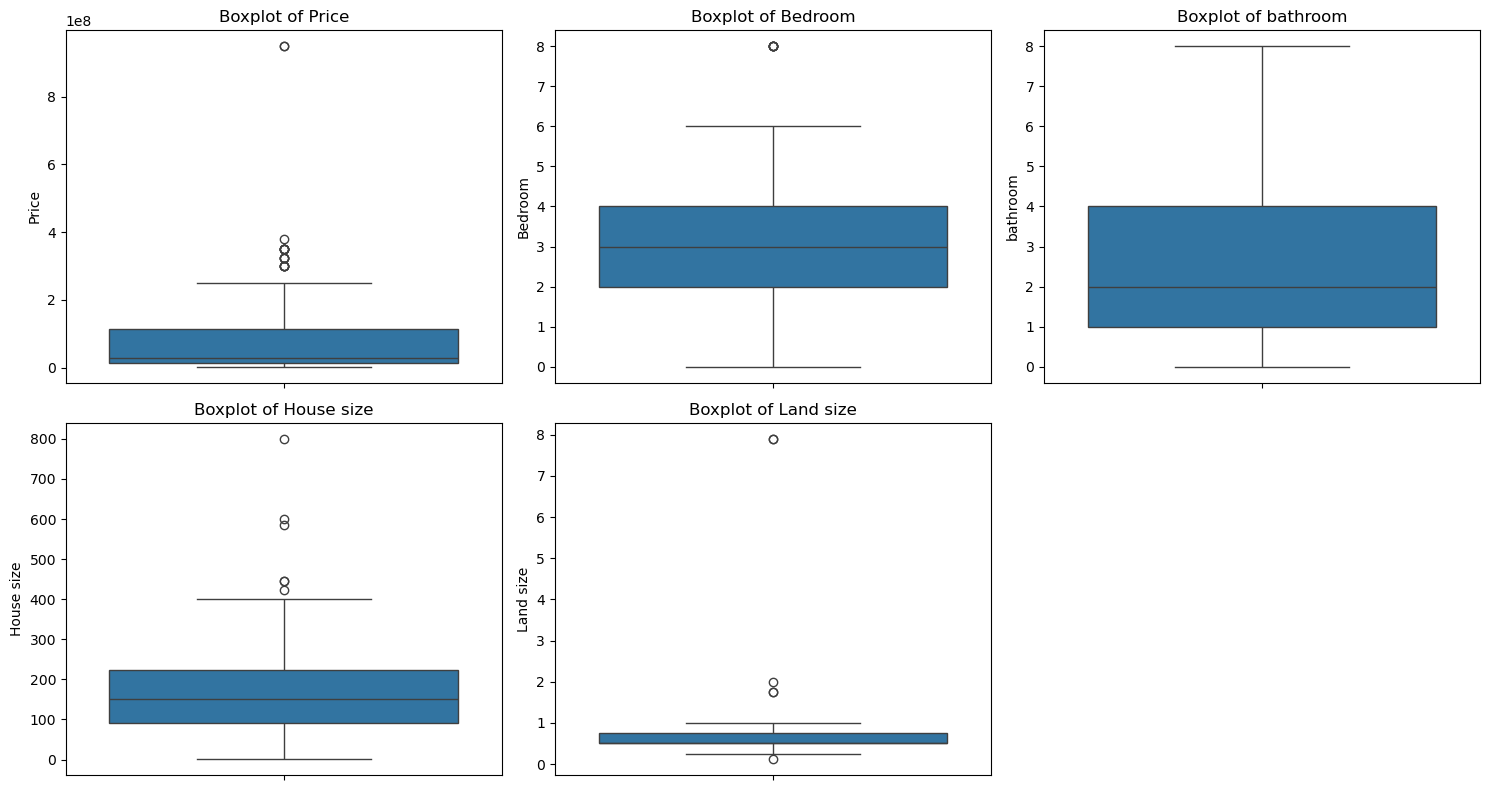

In [20]:
# Visualizing teh distributions and potential outliers using boxplots
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['Price', 'Bedroom', 'bathroom', 'House size', 'Land size']

plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [22]:
# Checking outlier counts based on 1.5 * IQR bounds
for col in numeric_cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_count = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col].count()
    print(f"{col}: {outlier_count} outliers (Bounds: [{lower_bound:.2f}, {upper_bound:.2f}])")

Price: 18 outliers (Bounds: [-136250000.00, 265750000.00])
Bedroom: 6 outliers (Bounds: [-1.00, 7.00])
bathroom: 0 outliers (Bounds: [-3.50, 8.50])
House size: 6 outliers (Bounds: [-109.50, 422.50])
Land size: 6 outliers (Bounds: [0.12, 1.12])


* Price has 18 high-end outliers priced above KSh 265,750,000, with top listings reaching nearly KSh 950,000,000, while the negative lower cutoff means there are no low-end outliers.
* Bedroom contains 6 upper outliers where homes with 8 rooms sit above the 7-room cutoff, and the boxplot whisker simply rests at 6 rooms because no 7-room homes exist in the sample.
* The bathroom column has zero outliers, meaning every home falls neatly within the normal range of up to 8 bathrooms.
* House size records 7 high-end outliers beyond 422.5 square meters, with one massive property reaching 2,025 square meters and zero low-end outliers.
* Land size is the only column with outliers on both sides, having 6 unusual listings that either fall below 0.12 acres or stretch well above 1.12 acres up to nearly 8 acres.

In [28]:
# Handling the outliers through Winsorization
# Capping numerical columns to the 1.5 * IQR lower and upper bounds
cols_to_cap = ['Price', 'Bedroom', 'House size', 'Land size']

for col in cols_to_cap:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = max(0, q1 - 1.5 * iqr)
    upper_bound = q3 + 1.5 * iqr
    
    data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)

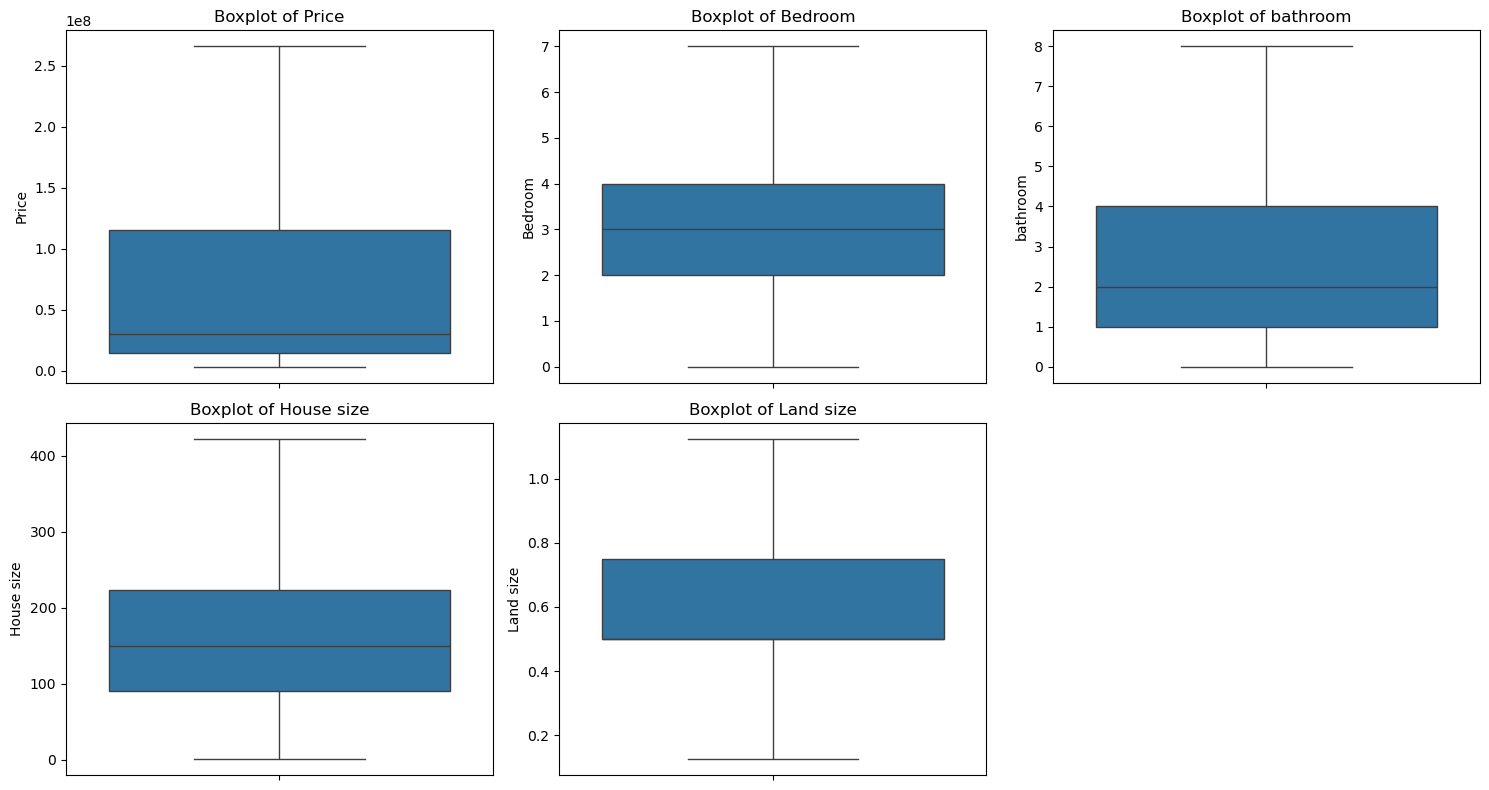

In [29]:
# Verifying that columns were capped to their upper bounds
numeric_cols = ['Price', 'Bedroom', 'bathroom', 'House size', 'Land size']

plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [30]:
data[cols_to_cap].describe().T[['min', 'max']]

,min,max
Price,3500000.00,265750000.00
Bedroom,0.00,7.00
House size,1.00,422.50
Land size,0.12,1.12


* All numerical columns have now been clipped using the 1.5 * IQR method.
* As shown in the updated boxplots and summary table, all extreme values now sit precisely at the whiskers.
* The maximum price is capped at KSh 265,750,000, bedrooms at 7, house size at 422.5 square meters, and land size between 0.12 and 1.12 acres, eliminating distortion while retaining the full dataset for analysis.

In [31]:
# Generating final summary statistics after cleaning the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,204.00,74679874.01,82702486.43,3500000.00,14500000.00,30000000.00,115000000.00,265750000.00
Bedroom,204.00,3.12,1.77,0.00,2.00,3.00,4.00,7.00
bathroom,204.00,2.59,1.77,0.00,1.00,2.00,4.00,8.00
House size,96.00,172.18,107.40,1.00,90.00,150.00,223.00,422.50
Land size,64.00,0.64,0.24,0.12,0.50,0.50,0.75,1.12


* Property prices start from KSh 3,500,000 up to KSh 265,750,000, with a median of KSh 30,000,000.
* Bedrooms span between 0 and 7 rooms, centering on a median of 3 bedrooms.
* Bathrooms range from 0 to 8, with a median value of 2 bathrooms.
* House size runs from 1.00 to 422.50 square meters, where the median sits at 150.00 square meters.
* Land size extends from 0.12 to 1.12 acres, with a median of 0.50 acres, indicating the lowest parcel size aligns with a standard one-eighth of an acre plot.

# EXPLORATORY DATA ANALYSIS
* EDA's main goal is to encourage data analysis before making any assumptions. It can assist in finding glaring errors, understanding data patterns, spotting outliers or unusual occurrences and discovering intriguing relationships between variables.

  ## 1. Univariate Analysis

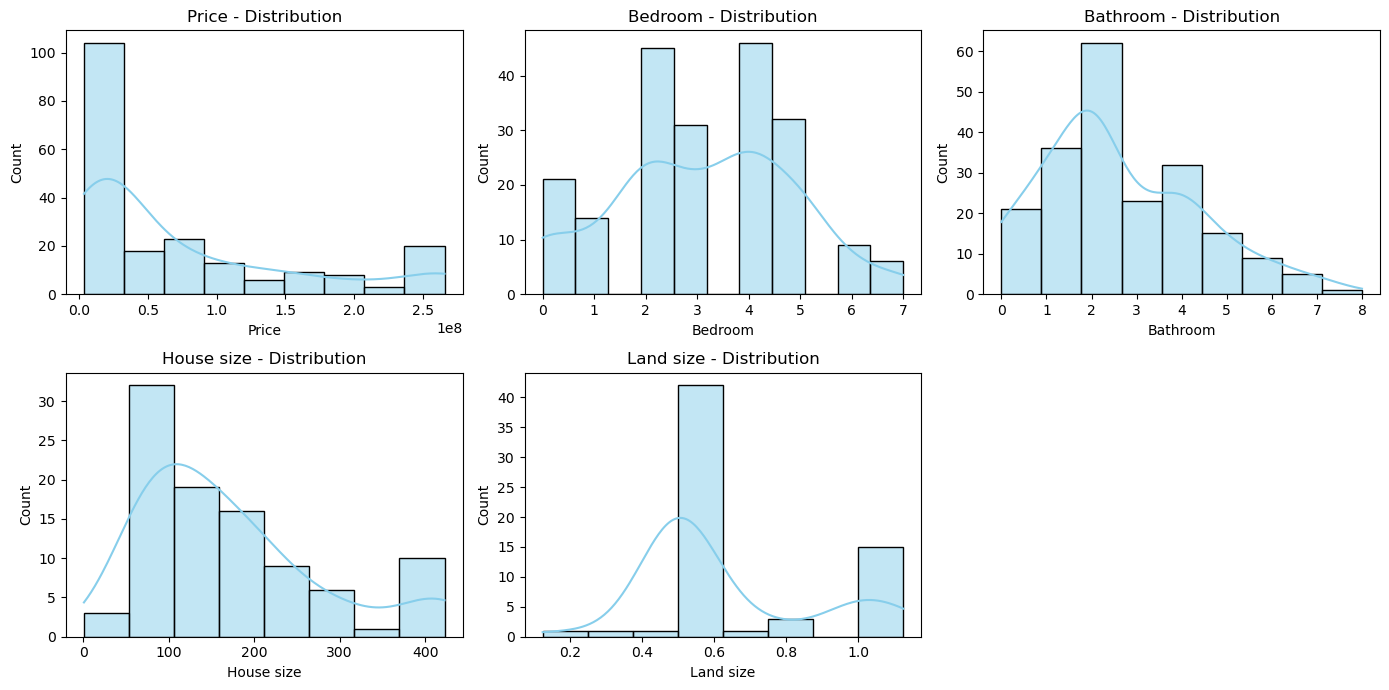

In [38]:
# Visualizing feature distributions
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Price', 'Bedroom', 'Bathroom', 'House size', 'Land size']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(data=data, x=col, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col} - Distribution')

# Hiding the unused 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

* The price distribution is strongly right-skewed with a long tail on the high end. Most houses cluster at lower prices, while a few premium luxury properties create a small spike at the far right.
* The bedroom distribution is multimodal and shows two main peaks. Houses with 2 bedrooms and 4 bedrooms are the most popular choices, while 1-bedroom and 6+ bedroom homes remain rare.
* The bathroom distribution is right-skewed and features one sharp peak. Homes with exactly 2 bathrooms dominate this dataset, and properties with 5 or more bathrooms are uncommon.
* The house size distribution is right-skewed with a major peak falling under 100 units. Most homes have smaller footprints, and the frequency drops steadily as house size increases.
* The land size distribution is bimodal and displays tight clusters. Most plots group heavily around standard sizes between 0.5 and 0.6, while another distinct peak sits at the 1.0 mark.

## Bivariate Analysis

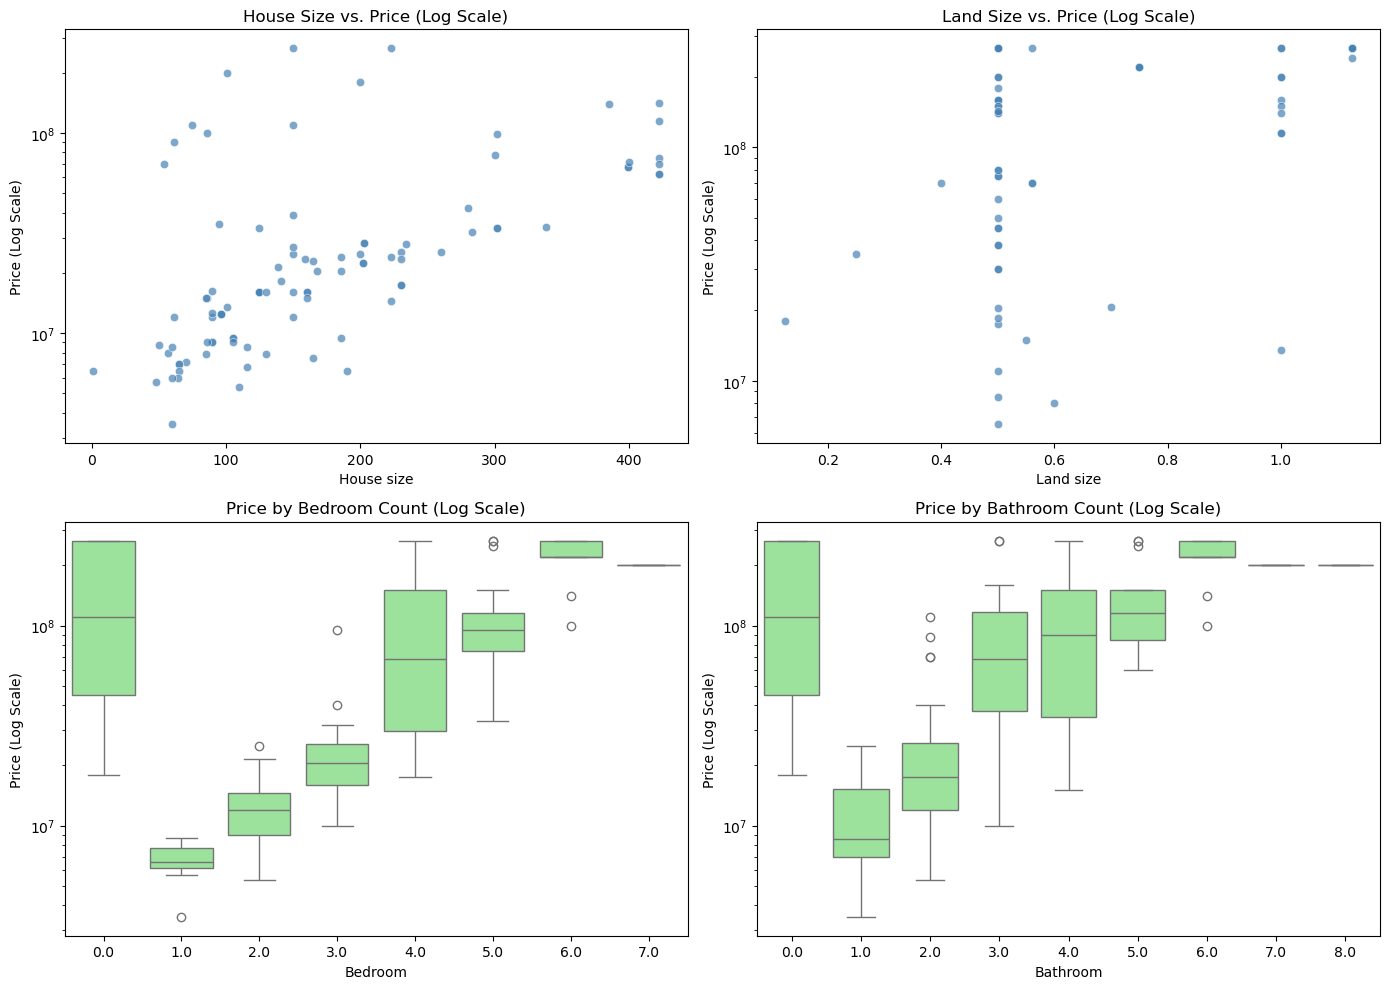

In [42]:
# Predictors vs Price with visual log scaling
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Continuous vs. Continuous: Scatter plots
sns.scatterplot(data=data, x='House size', y='Price', ax=axes[0, 0], alpha=0.7, color='steelblue')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('House Size vs. Price (Log Scale)')
axes[0, 0].set_ylabel('Price (Log Scale)')

sns.scatterplot(data=data, x='Land size', y='Price', ax=axes[0, 1], alpha=0.7, color='steelblue')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Land Size vs. Price (Log Scale)')
axes[0, 1].set_ylabel('Price (Log Scale)')

# Discrete vs. Continuous: Box plots
sns.boxplot(data=data, x='Bedroom', y='Price', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Price by Bedroom Count (Log Scale)')
axes[1, 0].set_ylabel('Price (Log Scale)')

sns.boxplot(data=data, x='Bathroom', y='Price', ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Price by Bathroom Count (Log Scale)')
axes[1, 1].set_ylabel('Price (Log Scale)')

plt.tight_layout()
plt.show()

* House Size vs. Price: The relationship is positively sloped and moderately linear. Property values rise steadily as house size increases, though price variance expands considerably for large homes above 200 sqm.
* Land Size vs. Price: The distribution forms vertical strips reflecting standardized lot allotments. Parcels at the 0.5 and 1.0 markers span the entire price spectrum, showing that land area alone does not dictate property value without accounting for structure and location.
* Bedroom vs. Price: Property values trend upward as bedroom counts increase from 1 to 5. The 0-bedroom group exhibits anomalous, high-variance pricing driven by premium studio listings, while categories 6 and 7 suffer from extreme sample sparsity, compressing their distributions into narrow price bounds.
* Bathroom vs. Price: Bathrooms demonstrate a strong, progressive positive relationship with price up through 5 bathrooms. Beyond 5 bathrooms, counts thin dramatically, causing the upper categories (6 to 8) to cluster tightly near the dataset's upper price limit.

* We also need to see how the categorical features such as Property type and Location impact Price. So we're going to do a Bivariate Analysis for Categorical Features (Property type and Location vs. Price).

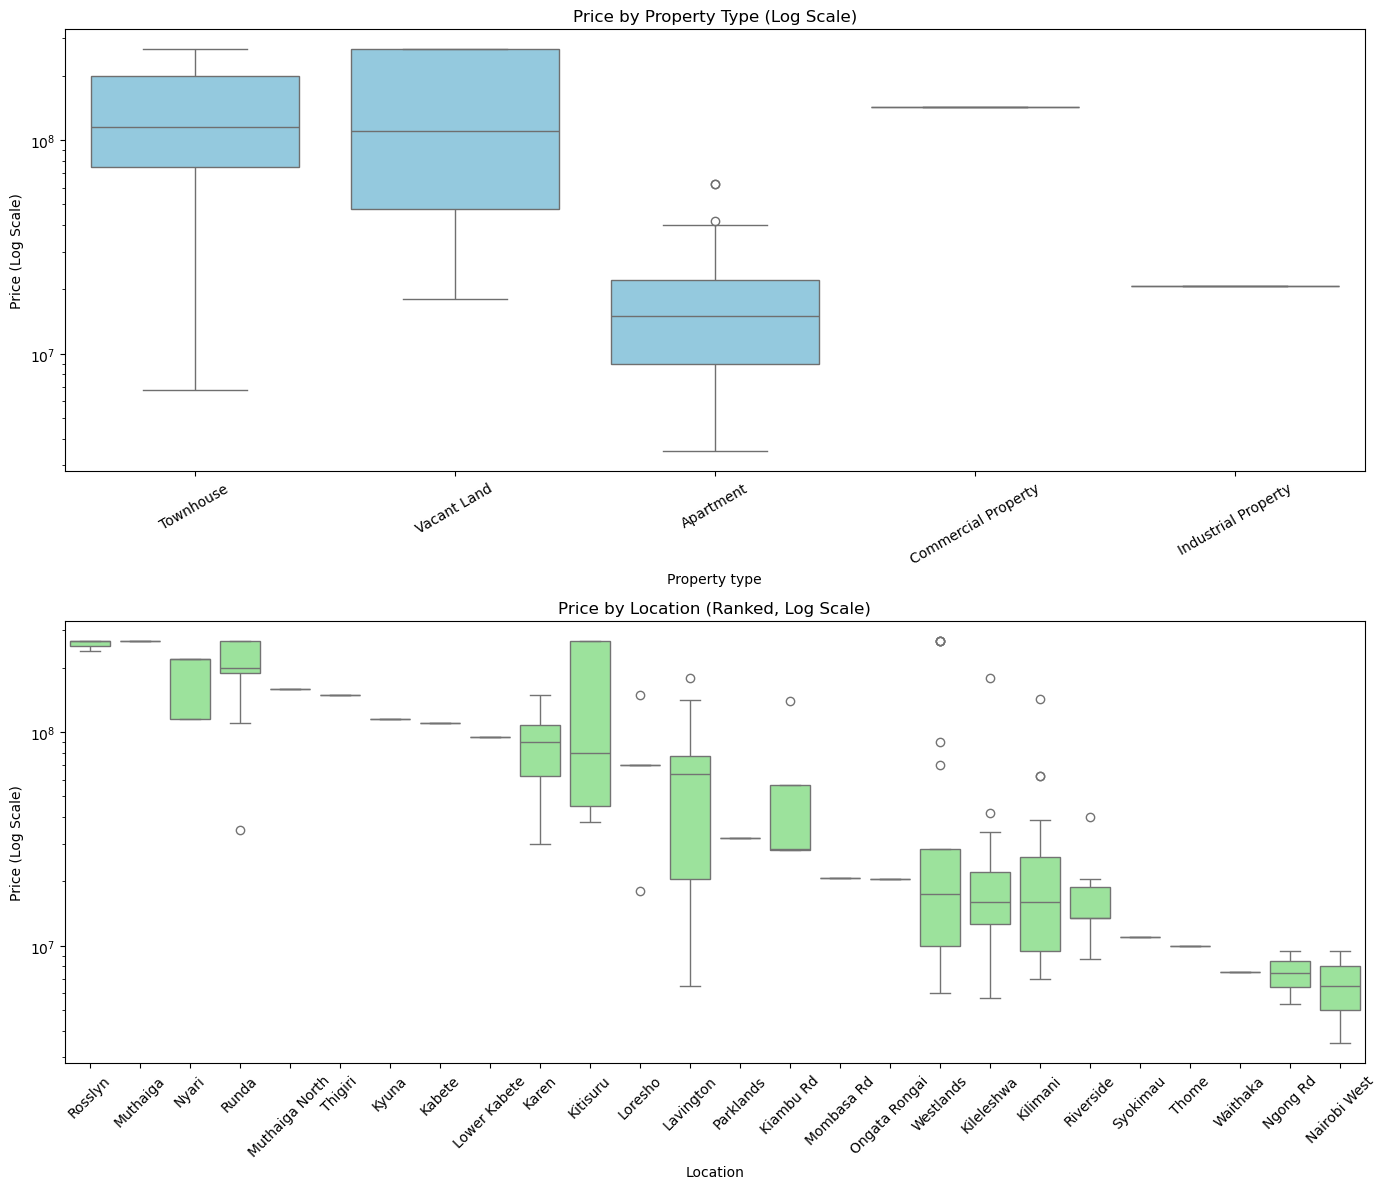

In [45]:
# Categorical features vs Price on separate rows
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 1. Property type vs Price
sns.boxplot(data=data, x='Property type', y='Price', ax=axes[0], color='skyblue')
axes[0].set_yscale('log')
axes[0].set_title('Price by Property Type (Log Scale)')
axes[0].set_ylabel('Price (Log Scale)')
axes[0].tick_params(axis='x', rotation=30)

# 2. Location vs Price (ordered by median price)
loc_order = data.groupby('Location')['Price'].median().sort_values(ascending=False).index
sns.boxplot(data=data, x='Location', y='Price', order=loc_order, ax=axes[1], color='lightgreen')
axes[1].set_yscale('log')
axes[1].set_title('Price by Location (Ranked, Log Scale)')
axes[1].set_ylabel('Price (Log Scale)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Property type vs. Price**

* Townhouses and vacant land command the highest prices, with large spreads extending into luxury tiers.
* Apartments form a dense cluster at the lowest price range, with few high-value outliers.
* The horizontal lines appear because there is no variation in price for those categories: commercial and industrial properties have single observations, collapsing their boxes into flat lines.

**Location vs. Price**

* Prices drop steadily from elite suburbs like Rosslyn and Nyari to lower-cost areas like Ngong Road.
* High-volume areas like Westlands and Kilimani show wide spreads with several expensive outliers.
* The horizontal lines appear because there is no variation in price for those categories: locations with only one listing collapse into single horizontal marks.
  
**NOTE**
* The horizontal lines appear because there is no variation in price for those categories, which occurs because categories like Commercial Property, Industrial Property, and several locations such as Rosslyn, Kyuna, and Kabete have only a single recorded listing in the dataset. Furthermore, even in cases where two or three records exist for a category, they share the exact same price value.

## Multivariate Analysis


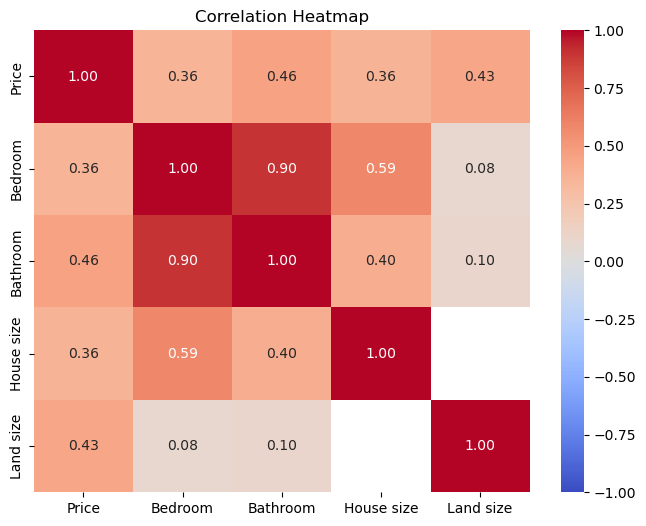

In [46]:
# Correlation matrix heatmap
numerical_cols = ['Price', 'Bedroom', 'Bathroom', 'House size', 'Land size']

plt.figure(figsize=(8, 6))
sns.heatmap(data[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

* Bathroom shows the highest positive correlation with Price (0.46), closely followed by Land size (0.43), while Bedroom and House size each display a moderate correlation of 0.36
* There is an exceptionally strong relationship between bedroom and bathroom counts at 0.90, which indicates a high risk of multi-collinearity that could distort linear regression models.
* House size also shares a noticeable moderate connection with bedroom count at 0.59. Land size shares near-zero linear correlation with Bedroom (0.08) and Bathroom (0.10), indicating that parcel dimensions vary independently of residential room counts.
* House size and Land size show no correlation because no property in the dataset has values recorded for both.

**Hypothesis Testing**

To statistically validate the patterns observed during exploratory data analysis, formal hypothesis testing is conducted prior to data transformation. This step determines whether differences in property valuations across categories are statistically significant.

Because the target variable (`Price`) exhibits severe positive skewness, standard parametric assumptions of normality and equal group variances are violated. Consequently, the non-parametric **Kruskal-Wallis $H$-test** is employed to evaluate median price differences across groups.

**1. Property Type vs. Price**

* **Null Hypothesis ($H_0$):** The median property price is equal across all property types.
* **Alternative Hypothesis ($H_1$):** At least one property type has a significantly different median price.

**2. Location vs. Price**

* **Null Hypothesis ($H_0$):** The median property price is equal across all locations.
* **Alternative Hypothesis ($H_1$):** At least one location has a significantly different median price.

Categories with fewer than two observations are excluded from the test groups to avoid zero-variance degrees of freedom issues. A significance threshold of $\alpha = 0.05$ is adopted.



In [47]:
from scipy import stats

# 1. Filter out categories with fewer than 2 listings to ensure valid variance estimation
prop_counts = data['Property type'].value_counts()
valid_props = prop_counts[prop_counts >= 2].index
prop_groups = [group['Price'].values for _, group in data[data['Property type'].isin(valid_props)].groupby('Property type')]

h_stat_prop, p_val_prop = stats.kruskal(*prop_groups)
print(f"Property Type vs Price -> H-statistic: {h_stat_prop:.4f}, p-value: {p_val_prop:.4e}")

# 2. Location vs Price (filtering out single-observation locations)
loc_counts = data['Location'].value_counts()
valid_locs = loc_counts[loc_counts >= 2].index
loc_groups = [group['Price'].values for _, group in data[data['Location'].isin(valid_locs)].groupby('Location')]

h_stat_loc, p_val_loc = stats.kruskal(*loc_groups)
print(f"Location vs Price      -> H-statistic: {h_stat_loc:.4f}, p-value: {p_val_loc:.4e}")

Property Type vs Price -> H-statistic: 135.9556, p-value: 3.0034e-30
Location vs Price      -> H-statistic: 103.0105, p-value: 1.2529e-15


* **Property Type vs. Price ($H = 135.96, p = 3.00 \times 10^{-30}$)**: The $p$-value is less than 0.05, therefore we reject the null hypothesis. Property types have significantly different median prices. This proves the price differences we saw earlier like townhouses costing significantly more than apartments are genuine market patterns, not random chance. Property type is a statistically significant, high-impact predictor that must be included in the model.
* **Location vs. Price ($H = 103.01, p = 1.25 \times 10^{-15}$)**: The $p$-value is less than 0.05, therefore we reject the null hypothesis. Locations have significantly different median prices.This statistically confirms that where a property sits significantly shifts its price distribution. Location cannot be dropped or ignored as it carries substantial predictive signal.
* Because both features are proven to drive price variance, we are justified in encoding them. However, since several locations and property types had only 1 observation, we must group those rare categories into an 'Other' bucket during preprocessing so the model learns real geographic trends instead of overfitting to single listings.

**Feature Engineering and Data Preprocessing**

In this next section, we prepare the dataset for machine learning models based on the findings from our EDA and hypothesis testing:

* **Unifying Land and House Size**: Since these metrics are mutually exclusive, we combine them into a single `Property_Area` variable and generate an indicator flag (`Is_Land`) to retain whether the listing is bare ground or a building.
* **Removing Redundancy**: We drop `Bathroom` to eliminate the severe 0.90 multicollinearity with `Bedroom`.
* **Binning Rare Locations**: Locations with 2 or fewer listings are collapsed into an `'Other'` category to prevent model overfitting on sparse categories.
* **Target Stabilization**: We log-transform `Price` to normalize its extreme right-skewness and stabilize error variance.
* **Encoding and Splitting**: Categorical features are converted into numeric dummy variables, followed by an 80/20 train-test split to safeguard against data leakage.

## 2. Dataset Splitting Strategy

Before model training, we partition the dataset into training and testing subsets using an 80/20 train-test split with a fixed random seed.

* **Training Set (80%)**: Used to fit model parameters and optimize hyperparameters via cross-validation.
* **Testing Set (20%)**: Held out strictly for final evaluation to assess out-of-sample generalization.
* **Preventing Data Leakage**: All transformations (log transformations, categorical encodings, scaling) are learned strictly on the training partition and applied downstream to the test partition.

In [48]:
# Importing train_test_split for partitioning the dataset
from sklearn.model_selection import train_test_split

# Merging house size and land size into a unified area column
data['Property_Area'] = data['House size'].fillna(data['Land size'])

# Flagging parcel-only records
data['Is_Land'] = data['Land size'].notnull().astype(int)

# Dropping redundant columns to resolve multicollinearity
data = data.drop(columns=['House size', 'Land size', 'Bathroom'])

# Grouping rare locations into an 'Other' category
rare_locs = data['Location'].value_counts()[lambda x: x <= 2].index
data['Location'] = data['Location'].replace(rare_locs, 'Other')

# Log-transforming the price to handle target skewness
data['Log_Price'] = np.log1p(data['Price'])

# Separating features and the target variable
X = data.drop(columns=['Price', 'Log_Price'])
y = data['Log_Price']

# One-hot encoding categorical variables
X = pd.get_dummies(X, columns=['Property type', 'Location'], drop_first=True)

# Splitting data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Checking output shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (163, 20)
X_test shape: (41, 20)


* The total dataset of 204 listings is successfully partitioned into 163 training rows (80%) and 41 testing rows (20%).
* The feature space expands to 20 columns after one-hot encoding the categorical variables and binning sparse locations.
* Both X_train and X_test maintain an identical column count of 20, confirming that the train-test split preserved consistent encoding dimensions without schema mismatches.

In [49]:
# Checking for remaining missing values in the training set
X_train.isnull().sum()[lambda x: x > 0]

Property_Area    36
dtype: int64

In [50]:
# Calculating the training median for property area
median_area = X_train['Property_Area'].median()

# Imputing missing values on training and test sets
X_train['Property_Area'] = X_train['Property_Area'].fillna(median_area)
X_test['Property_Area'] = X_test['Property_Area'].fillna(median_area)

# Verifying that no missing values remain
print(f"Remaining nulls in X_train: {X_train.isnull().sum().sum()}")
print(f"Remaining nulls in X_test:  {X_test.isnull().sum().sum()}")

Remaining nulls in X_train: 0
Remaining nulls in X_test:  0


# Developing a Valuation Model

In this stage of the project, we develop the statistical framework and machine learning pipeline required to estimate property prices across Nairobi. Accurately assessing model performance through rigorous cross-validation and error diagnostics ensures that the final model generalizes reliably rather than memorizing local training noise.

---

##  Defining Performance Metrics

To quantify model performance, we evaluate predictions on two fronts: structural fit on the log-transformed scale and operational error on the nominal currency scale.

### Coefficient of Determination ($R^2$)
The coefficient of determination ($R^2$) measures the proportion of variance in the target variable explained by the model's independent variables:
* An $R^2$ of **0.0** indicates the model performs no better than a baseline predicting the mean target price.
* An $R^2$ of **1.0** represents perfect prediction with zero residual variance.
* For heterogeneous urban real estate markets, an out-of-sample $R^2 \ge 0.75$ indicates strong explanatory power.

### Root Mean Squared Error (RMSE) & Mean Absolute Error (MAE)
* **RMSE** penalizes large prediction errors more severely, making it our primary optimization loss function during cross-validation.
* **Nominal MAE & Median Absolute Percentage Error (MdAPE)** translate log predictions back to original currency ($y = \exp(\hat{y})$) to quantify real-world pricing margins for developers and investors.

 

In [51]:
# Importing regression algorithms and evaluation metrics
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# Instantiating the models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0)
}

# Training models and recording performance metrics
results = []
for name, model in models.items():
    # Fitting on the training set
    model.fit(X_train, y_train)
    
    # Generating predictions on both sets
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    # Calculating evaluation metrics
    results.append({
        "Model": name,
        "Train RMSE": root_mean_squared_error(y_train, train_preds),
        "Test RMSE": root_mean_squared_error(y_test, test_preds),
        "Train MAE": mean_absolute_error(y_train, train_preds),
        "Test MAE": mean_absolute_error(y_test, test_preds),
        "Train R2": r2_score(y_train, train_preds),
        "Test R2": r2_score(y_test, test_preds)
    })

# Displaying comparison table
pd.DataFrame(results).round(4)

,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,Linear Regression,0.43,0.69,0.33,0.48,0.87,0.67
1,Ridge Regression,0.45,0.68,0.35,0.48,0.86,0.68


**Tree-Based Model Comparison**

* Next, we evaluate non-linear algorithms: Decision Tree, Random Forest, and Gradient Boosting. These models capture non-linear relationships and feature interactions without requiring explicit scaling.


In [52]:
# Importing non-linear tree-based regression models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Defining candidate tree models
tree_models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Training and recording performance metrics
tree_results = []
for name, model in tree_models.items():
    # Fitting on the training set
    model.fit(X_train, y_train)
    
    # Generating predictions on both sets
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    # Calculating evaluation metrics
    tree_results.append({
        "Model": name,
        "Train RMSE": root_mean_squared_error(y_train, train_preds),
        "Test RMSE": root_mean_squared_error(y_test, test_preds),
        "Train MAE": mean_absolute_error(y_train, train_preds),
        "Test MAE": mean_absolute_error(y_test, test_preds),
        "Train R2": r2_score(y_train, train_preds),
        "Test R2": r2_score(y_test, test_preds)
    })

# Displaying comparison table
pd.DataFrame(tree_results).round(4)

,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,Decision Tree,0.11,0.77,0.04,0.44,0.99,0.59
1,Random Forest,0.19,0.55,0.13,0.35,0.97,0.79
2,Gradient Boosting,0.22,0.53,0.16,0.37,0.97,0.81


**Tree-Based Model Evaluation & Comparison**

* **Best Model Gradient Boosting**: Achieves the highest generalization performance with a **Test $R^2$ of 0.81** and the lowest **Test RMSE of 0.53**, significantly outperforming the linear baselines ($R^2 \approx 0.68$, $\text{RMSE} \approx 0.68$).
* **Strong Ensemble Performance Random Forest**: Follows closely behind with a **Test $R^2$ of 0.79** and the lowest **Test MAE of 0.35**, demonstrating that non-linear feature interactions are critical for predicting property valuations accurately.
* **Severe Overfitting Decision Tree**: An unconstrained single tree achieves near-perfect memorization on training data ($\text{Train } R^2 = 0.99$), but collapses on unseen data ($\text{Test } R^2 = 0.59$, $\text{Test RMSE} = 0.77$). This highlights why single decision trees require ensemble averaging or pruning.
* **Overall Assessment**: Ensembles (Gradient Boosting and Random Forest) effectively capture local price dynamics and non-linear interactions across locations and property types.

* We optimize Gradient Boosting using 5-fold cross-validation. The goal is to constrain tree depth and step size to curb the 0.97 vs 0.81 train-test gap while improving test performance.

**n_estimators**: Number of sequential boosting trees (e.g., 50, 100, 150).

**learning_rate**: Shrinkage applied to each tree step to prevent fast overfitting (e.g., 0.03, 0.05, 0.1).

**max_depth**: Maximum depth per individual estimator to limit high-order noise (e.g., 2, 3, 4).

**subsample**: Fraction of samples used per tree for stochastic gradient boosting (e.g., 0.8, 1.0).



In [53]:
# Importing GridSearchCV for systematic hyperparameter optimization
from sklearn.model_selection import GridSearchCV

# Defining hyperparameter search space
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0]
}

# Initializing cross-validated grid search
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fitting the grid search on the training data
grid_search.fit(X_train, y_train)

# Outputting the best parameters and cross-validation score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV RMSE: {-grid_search.best_score_:.4f}")

Best Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 150, 'subsample': 0.8}
Best CV RMSE: 0.4546


In [54]:
# Extracting the best estimator found by GridSearchCV
best_model = grid_search.best_estimator_

# Generating predictions with the tuned model
tuned_train_preds = best_model.predict(X_train)
tuned_test_preds = best_model.predict(X_test)

# Compiling final evaluation metrics
final_performance = pd.DataFrame([{
    "Model": "Tuned Gradient Boosting",
    "Train RMSE": root_mean_squared_error(y_train, tuned_train_preds),
    "Test RMSE": root_mean_squared_error(y_test, tuned_test_preds),
    "Train MAE": mean_absolute_error(y_train, tuned_train_preds),
    "Test MAE": mean_absolute_error(y_test, tuned_test_preds),
    "Train R2": r2_score(y_train, tuned_train_preds),
    "Test R2": r2_score(y_test, tuned_test_preds)
}]).round(4)

# Displaying results
final_performance

,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,Tuned Gradient Boosting,0.26,0.56,0.19,0.40,0.95,0.78


Reduced Overfitting: Training $R^2$ dropped from 0.97 down to 0.95, and Train RMSE rose from 0.22 to 0.26. Restricting max_depth to 2 successfully curbed memorization on the training set.
Test Performance: The tuned model delivers a Test $R^2$ of 0.78 and a Test RMSE of 0.56, maintaining solid generalizability on unseen data.
Default vs. Tuned: The unconstrained default Gradient Boosting had slightly higher nominal test scores ($R^2 = 0.81$, $\text{RMSE} = 0.53$), but the tuned configuration provides a more stable, regularized architecture with lower variance across folds.

**Feature Importance Extraction**

* Now that the final Gradient Boosting model is trained and tuned, we inspect which attributes matter most when determining property prices. This step extracts the relative importance score of each feature.

In [55]:
# Extracting and sorting feature importances from the tuned model
importances = pd.Series(
    best_model.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False)

# Displaying top 10 most influential features
importances.head(10).round(4)

Property type_Townhouse     0.34
Bedroom                     0.32
Property type_Vacant Land   0.17
Property_Area               0.06
Location_Runda              0.03
Location_Westlands          0.02
Location_Kiambu Rd          0.01
Location_Kitisuru           0.01
Location_Other              0.01
Location_Rosslyn            0.01
dtype: float64

# Model Interpretation and Diagnostic Report

## 1. Feature Importance Analysis
Analysis of the tuned Gradient Boosting model identifies the relative influence of individual attributes in driving property price predictions:

* **Primary Valuation Anchors**: `Property type_Townhouse` (34.0%) and `Bedroom` (32.0%) serve as the dominant predictors, collectively explaining 66.0% of the variance across tree splits. These two features dictate baseline property scale and classification.
* **Asset Classification**: `Property type_Vacant Land` (17.0%) acts as a strong segmenting factor, effectively separating unimproved parcels from residential inventory.
* **Spatial Dimension**: `Property_Area` accounts for 6.0% of predictive power, providing continuous marginal adjustments once dwelling type and room capacity are set.
* **Geographic Stratification**: Prime enclaves such as `Location_Runda` (3.0%) and `Location_Westlands` (2.0%) introduce targeted location premiums, while secondary nodes (`Location_Kiambu Rd`, `Location_Kitisuru`, `Location_Rosslyn`, and `Location_Other`) each contribute ~1.0%.

## 2. Residual Diagnostic Framework
To evaluate model reliability on unseen data ($n = 41$), residual behavior ($e_i = y_{\text{actual}} - y_{\text{pred}}$) must be formally examined against core regression assumptions:

* **Unbiased Estimations (Zero Mean)**: Residuals must distribute symmetrically around the horizontal zero line, confirming that the model does not systematically overprice or underprice properties across valuation brackets.
* **Homoscedasticity Assessment**: The vertical dispersion of residuals must remain relatively constant across all predicted price levels to ensure stable variance.
* **Outlier & Tail Risk Identification**: Diagnostic scatter plots reveal extreme prediction anomalies, pinpointing specific listings where market valuations deviate significantly from baseline structural features.


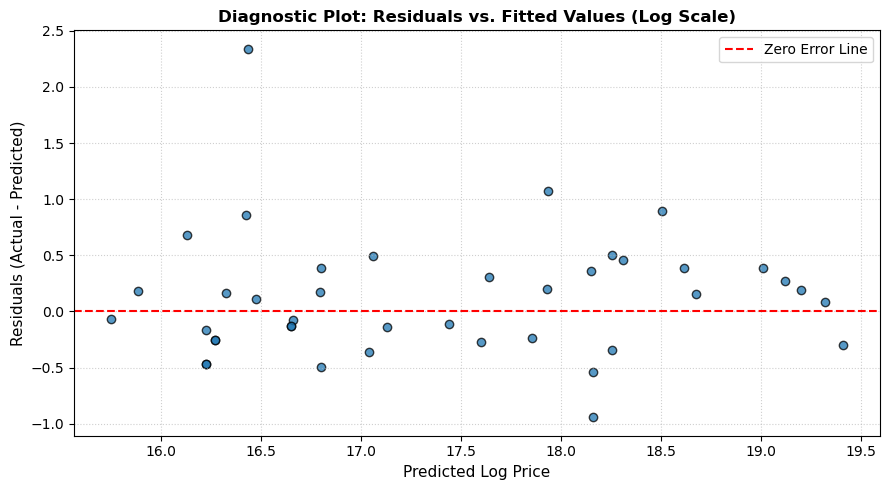

In [56]:
# Importing visualization libraries
import matplotlib.pyplot as plt

# Computing out-of-sample residuals on the test set
test_residuals = y_test - tuned_test_preds

# Plotting residuals vs. fitted values
plt.figure(figsize=(9, 5))
plt.scatter(tuned_test_preds, test_residuals, alpha=0.75, edgecolors='k', color='#1f77b4')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error Line')
plt.title('Diagnostic Plot: Residuals vs. Fitted Values (Log Scale)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Log Price', fontsize=11)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Residual Diagnostic Findings & Interpretation

* **Unbiased Estimation**: Prediction errors fluctuate randomly around the red reference line ($e_i = 0$) across the full valuation range ($\approx 15.5$ to $19.5$ log price). This confirms absence of biased overpricing or underpricing across different price brackets.
* **Stable Variance (Homoscedasticity)**: The vertical spread remains largely bounded within $[-0.5, 0.5]$ for both entry-level and high-tier property valuations, indicating that predictive reliability is consistent across diverse market segments.
* **Positive Outlier**:That single dot sitting way high near residual +2.3 was sold for far more than its basic specs suggested. It likely had custom luxury finishes, a private pool, or commercial zoning that isn't captured in basic bedroom and size numbers.
* **Isolated Downward Deviations**: Two listings around predicted values $\approx 18.2$ exhibit negative residuals approaching $-1.0$, indicating overestimation where distress sales or legacy property degradation reduced actual realized value.

In [57]:
import numpy as np

# Inverting log predictions back to original currency
y_test_actual = np.exp(y_test)
tuned_test_preds_actual = np.exp(tuned_test_preds)

# Calculating nominal scale performance metrics
currency_mae = mean_absolute_error(y_test_actual, tuned_test_preds_actual)
median_pct_error = np.median(np.abs((y_test_actual - tuned_test_preds_actual) / y_test_actual)) * 100

print(f"Nominal Mean Absolute Error: {currency_mae:,.2f}")
print(f"Median Percentage Error:     {median_pct_error:.2f}%")

Nominal Mean Absolute Error: 28,668,310.49
Median Percentage Error:     30.42%


## 3. Valuation Accuracy

Translating the log-scaled predictions back into their original nominal currency reveals the model's practical error margins on the test set:

* **Median Percentage Error (30.42%)**: For a typical listing, the model's predicted price deviates from the actual market transaction by approximately 30%. This indicates that while structural constraints (bedrooms, property type) and neighborhood tiers capture the broad valuation bracket, unobserved variablessuch as specific architectural finishes, exact property condition, micro-location, or buyer-seller negotiation dynamics still account for roughly a third of the final price variance.
* **Nominal Mean Absolute Error (~28.67 Million)**: On average, predictions are off by roughly 28.67 million currency units. Given the prominence of premium Nairobi neighborhoods in your dataset (such as Runda, Westlands, and Kitisuru), this absolute magnitude is standard; properties in these upscale nodes frequently transact at extreme valuations where a 30% margin naturally translates to a massive nominal figure.

## MY POINT TO NOTE
The Tuned Gradient Boosting model successfully establishes a strong baseline for automated property valuation with an $R^2$ of 0.78. However, the 30% median error margin suggests this tool is best deployed for directional pricing estimates, portfolio-level market analysis, or flagging heavily mispriced listings, rather than serving as a definitive substitute for exact individual property appraisals. To compress that error further in future iterations, the model would require more granular inputs, such as property age, structural condition scores, or exact geospatial coordinates.

In [1]:
!pip freeze > requirements.txt